# Developing an Early Warning System for Measles Outbreaks Using AI

#### Author: Megan Chastain      
#### July 2026

## Abstract

## Imports


In [2]:
import pandas as pd
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pandas.plotting import scatter_matrix
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
reg = LinearRegression()
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree


ModuleNotFoundError: No module named 'sklearn'

In [3]:
# Load  dataset
measles = pd.read_csv("../data/measles_county_all_updates.csv")
columns = [
    "location_name","location_id","location_type","date","Outcome-type","value"
] 

measles.head(10)

,location_name,location_id,location_type,date,outcome_type,value
0,"Adams, Colorado",8001.0,county,2025-08-13,case_lab-confirmed,1
1,"Adams, Colorado",8001.0,county,2025-08-15,case_lab-confirmed,2
2,"Adams, Colorado",8001.0,county,2025-08-28,case_lab-confirmed,1
3,"Adams, Colorado",8001.0,county,2026-03-06,case_lab-confirmed,5
4,"Alachua, Florida",12001.0,county,2026-01-25,case_lab-confirmed,1
5,"Alachua, Florida",12001.0,county,2026-02-07,case_lab-confirmed,1
6,"Allegan, Michigan",26005.0,county,2025-06-06,case_lab-confirmed,1
7,"Allen, Indiana",18003.0,county,2025-04-07,case_lab-confirmed,1
8,"Allen, Indiana",18003.0,county,2025-04-09,case_lab-confirmed,5
9,"Allen, Indiana",18003.0,county,2025-04-23,case_lab-confirmed,2


In [5]:
print((measles == '?').sum())

location_name    0
location_id      0
location_type    0
date             0
outcome_type     0
value            0
dtype: int64


In [9]:
print(measles.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1229 entries, 0 to 1228
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   location_name  1229 non-null   object 
 1   location_id    1225 non-null   float64
 2   location_type  1229 non-null   object 
 3   date           1229 non-null   object 
 4   outcome_type   1229 non-null   object 
 5   value          1229 non-null   int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 57.7+ KB
None


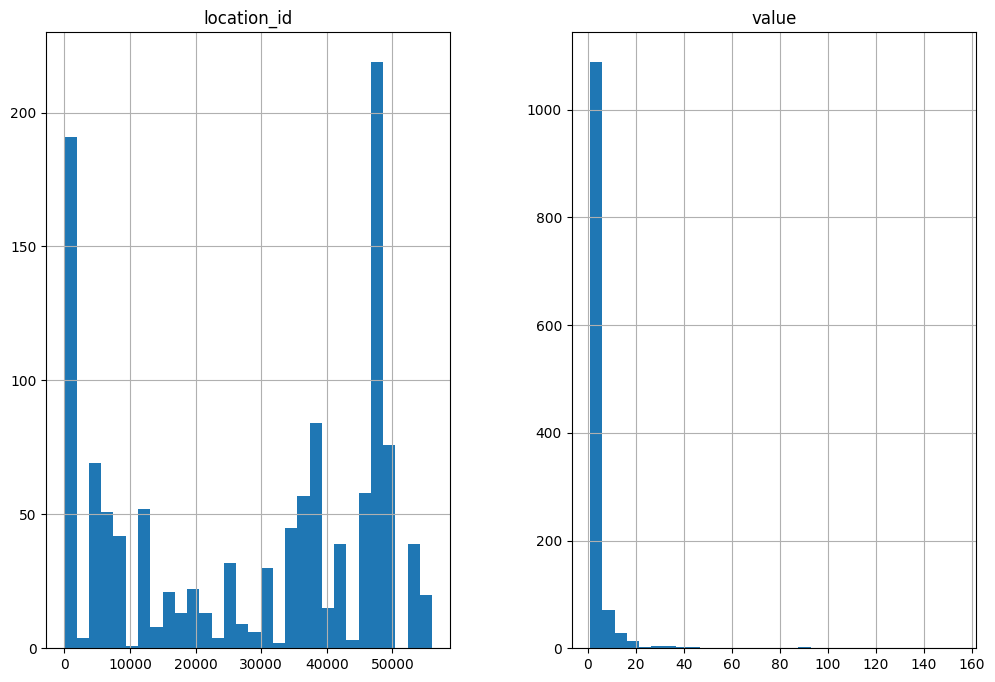

In [8]:
measles.hist(bins=30, figsize=[12,8])
plt.show()

In [ ]:
# Load  dataset
census = pd.read_csv("../data/county_demographics.csv")
columns = [
    "year","statefips","countyfips","state","TotalPop","MalePct","WhitePct","BlackPct","OtherRacePct","ChildrenPct","AdultPct","SeniorPct","location_id","county_name","state_abb","state_code","county_code",
] 

census.head(10)

,year,statefips,countyfips,state,TotalPop,MalePct,WhitePct,BlackPct,OtherRacePct,ChildrenPct,AdultPct,SeniorPct,location_id,county_name,state_abb,state_code,county_code
0,1969,1,1,AL,23819,48.771992,71.039925,28.880306,0.079768,41.991688,58.008312,7.422646,1001.0,AUTAUGA,AL,1.0,1.0
1,1969,1,3,AL,58915,48.841553,81.739792,18.075193,0.185012,37.662735,62.337265,10.209624,1003.0,BALDWIN,AL,1.0,2.0
2,1969,1,5,AL,22199,46.146225,53.601513,46.317402,0.081085,37.573765,62.426235,10.856345,1005.0,BARBOUR,AL,1.0,3.0
3,1969,1,7,AL,13739,48.977364,71.569984,28.371788,0.058228,37.833904,62.166096,11.245360,1007.0,BIBB,AL,1.0,4.0
4,1969,1,9,AL,26267,49.244297,97.536835,2.394640,0.068527,33.966576,66.033424,10.423725,1009.0,BLOUNT,AL,1.0,5.0
5,1969,1,11,AL,12069,46.648438,32.571049,67.412376,0.016571,42.008450,57.991550,12.030823,1011.0,BULLOCK,AL,1.0,6.0
6,1969,1,13,AL,22088,47.057224,59.625137,40.316010,0.058855,36.979355,63.020645,12.509055,1013.0,BUTLER,AL,1.0,7.0
7,1969,1,15,AL,102757,48.194283,82.741806,17.051880,0.206312,34.120304,65.879700,7.600455,1015.0,CALHOUN,AL,1.0,8.0
8,1969,1,17,AL,36403,47.377964,65.140236,34.802078,0.057688,34.988876,65.011124,10.433206,1017.0,CHAMBERS,AL,1.0,9.0
9,1969,1,19,AL,15034,49.827061,90.993744,8.919782,0.086471,33.131569,66.868431,10.602634,1019.0,CHEROKEE,AL,1.0,10.0


In [ ]:
print((census == '?').sum())

year            0
statefips       0
countyfips      0
state           0
TotalPop        0
MalePct         0
WhitePct        0
BlackPct        0
OtherRacePct    0
ChildrenPct     0
AdultPct        0
SeniorPct       0
location_id     0
county_name     0
state_abb       0
state_code      0
county_code     0
dtype: int64


In [ ]:
print(census.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171760 entries, 0 to 171759
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          171760 non-null  int64  
 1   statefips     171760 non-null  int64  
 2   countyfips    171760 non-null  int64  
 3   state         171760 non-null  object 
 4   TotalPop      171760 non-null  int64  
 5   MalePct       171760 non-null  float64
 6   WhitePct      171760 non-null  float64
 7   BlackPct      171760 non-null  float64
 8   OtherRacePct  171760 non-null  float64
 9   ChildrenPct   171760 non-null  float64
 10  AdultPct      171760 non-null  float64
 11  SeniorPct     171760 non-null  float64
 12  location_id   171363 non-null  float64
 13  county_name   171363 non-null  object 
 14  state_abb     171363 non-null  object 
 15  state_code    171363 non-null  float64
 16  county_code   171328 non-null  float64
dtypes: float64(10), int64(4), object(3)
memory usage

In [14]:
# Quick conceptual merge in pandas
import pandas as pd

measles = pd.read_csv("../data/measles_county_all_updates.csv")
census = pd.read_csv("../data/county_demographics.csv")

# Ensure FIPS codes are padded strings (e.g., '01001' instead of 1001) to prevent data loss
measles['location_id'] = measles['location_id'].astype(str).str.zfill(5)
census['location_id'] = census['location_id'].astype(str).str.zfill(5)

# Merge datasets
df = pd.merge(measles, census, on='location_id', how='left')

In [15]:
df.head(10)

,location_name,location_id,location_type,date,outcome_type,value,year,statefips,countyfips,state,...,WhitePct,BlackPct,OtherRacePct,ChildrenPct,AdultPct,SeniorPct,county_name,state_abb,state_code,county_code
0,"Adams, Colorado",8001.0,county,2025-08-13,case_lab-confirmed,1,2002.0,8.0,1.0,CO,...,90.536560,3.727549,5.735894,28.133554,71.866447,7.851858,ADAMS,CO,6.0,1.0
1,"Adams, Colorado",8001.0,county,2025-08-13,case_lab-confirmed,1,2003.0,8.0,1.0,CO,...,90.416039,3.694127,5.889833,28.213816,71.786186,7.855054,ADAMS,CO,6.0,1.0
2,"Adams, Colorado",8001.0,county,2025-08-13,case_lab-confirmed,1,2004.0,8.0,1.0,CO,...,90.289467,3.692481,6.018051,28.249340,71.750664,7.873257,ADAMS,CO,6.0,1.0
3,"Adams, Colorado",8001.0,county,2025-08-13,case_lab-confirmed,1,2005.0,8.0,1.0,CO,...,90.134026,3.712805,6.153169,28.501110,71.498886,7.836850,ADAMS,CO,6.0,1.0
4,"Adams, Colorado",8001.0,county,2025-08-13,case_lab-confirmed,1,2006.0,8.0,1.0,CO,...,89.986351,3.785525,6.228125,28.599398,71.400604,7.949087,ADAMS,CO,6.0,1.0
5,"Adams, Colorado",8001.0,county,2025-08-13,case_lab-confirmed,1,2007.0,8.0,1.0,CO,...,89.799057,3.830945,6.369995,28.664858,71.335144,8.021725,ADAMS,CO,6.0,1.0
6,"Adams, Colorado",8001.0,county,2025-08-13,case_lab-confirmed,1,2008.0,8.0,1.0,CO,...,89.535271,3.912330,6.552400,28.607973,71.392029,8.150374,ADAMS,CO,6.0,1.0
7,"Adams, Colorado",8001.0,county,2025-08-13,case_lab-confirmed,1,2009.0,8.0,1.0,CO,...,89.342667,3.929539,6.727794,28.687399,71.312599,8.246959,ADAMS,CO,6.0,1.0
8,"Adams, Colorado",8001.0,county,2025-08-13,case_lab-confirmed,1,2010.0,8.0,1.0,CO,...,89.094383,3.965945,6.939672,28.535919,71.464081,8.362761,ADAMS,CO,6.0,1.0
9,"Adams, Colorado",8001.0,county,2025-08-13,case_lab-confirmed,1,2011.0,8.0,1.0,CO,...,88.938454,4.028611,7.032939,28.461100,71.538902,8.472549,ADAMS,CO,6.0,1.0


In [17]:
df.to_csv("../data/measles_joined.csv", index=False)